# Gold analytics: stress scores & trends
This notebook reads the **Gold** Delta table and provides a few ready-to-run analyses:
- Daily distribution & average of `score_stress`
- Top subreddits by average `score_stress`
- Simple visualizations

> Tip: Run `../00_setup/spark_local.ipynb` first. If not, this notebook will bootstrap Spark with default settings.

In [1]:
import os
from pyspark.sql import SparkSession

# ---- Environment (override via env vars if needed) ----
S3A_ENDPOINT = os.getenv('S3A_ENDPOINT', 'http://localhost:9000')
S3A_ACCESS   = os.getenv('S3A_ACCESS_KEY', 'minio')
S3A_SECRET   = os.getenv('S3A_SECRET_KEY', 'minio123')
DELTA_LOG    = 'org.apache.spark.sql.delta.storage.S3SingleDriverLogStore'
BUCKET       = os.getenv('MINIO_BUCKET', 'datalake')

# ---- Spark config ----
SPARK_VERSION = "3.5.1"
SCALA_BINARY  = "2.12"
DELTA_VERSION = "3.2.0"
HADOOP_AWS_VERSION = "3.3.4"
AWS_SDK_BUNDLE_VERSION = "1.12.767"

packages = ",".join([
    f"io.delta:delta-spark_{SCALA_BINARY}:{DELTA_VERSION}",
    f"org.apache.hadoop:hadoop-aws:{HADOOP_AWS_VERSION}",
    f"com.amazonaws:aws-java-sdk-bundle:{AWS_SDK_BUNDLE_VERSION}",
])

# ---- Build Spark ----
spark = (
    SparkSession.builder
    .appName('nb-local')
    .master('local[*]')
    .config('spark.jars.packages', packages)
    .config('spark.sql.extensions','io.delta.sql.DeltaSparkSessionExtension')
    .config('spark.sql.catalog.spark_catalog','org.apache.spark.sql.delta.catalog.DeltaCatalog')
    .config('spark.hadoop.fs.s3a.endpoint', S3A_ENDPOINT)
    .config('spark.hadoop.fs.s3a.access.key', S3A_ACCESS)
    .config('spark.hadoop.fs.s3a.secret.key', S3A_SECRET)
    .config('spark.hadoop.fs.s3a.path.style.access','true')
    .config('spark.hadoop.fs.s3a.connection.ssl.enabled','false')
    .config('spark.hadoop.fs.s3a.impl','org.apache.hadoop.fs.s3a.S3AFileSystem')
    .config('spark.delta.logStore.class', DELTA_LOG)
    .getOrCreate()
)

# ---- Common paths ----
bronze_path = f's3a://{BUCKET}/bronze/reddit_posts'
silver_path = f's3a://{BUCKET}/silver/reddit_posts'
gold_path   = f's3a://{BUCKET}/gold/reddit_posts'
bronze_path, silver_path, gold_path

:: loading settings :: url = jar:file:/Users/khanhdo/Workplace/Karhdo/reddit-stress-streaming/venv/lib/python3.11/site-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /Users/khanhdo/.ivy2/cache
The jars for the packages stored in: /Users/khanhdo/.ivy2/jars
io.delta#delta-spark_2.12 added as a dependency
org.apache.hadoop#hadoop-aws added as a dependency
com.amazonaws#aws-java-sdk-bundle added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-0f5a9fc2-197e-4330-a017-2ede8075c7ab;1.0
	confs: [default]
	found io.delta#delta-spark_2.12;3.2.0 in central
	found io.delta#delta-storage;3.2.0 in central
	found org.antlr#antlr4-runtime;4.9.3 in central
	found org.apache.hadoop#hadoop-aws;3.3.4 in central
	found org.wildfly.openssl#wildfly-openssl;1.0.7.Final in central
	found com.amazonaws#aws-java-sdk-bundle;1.12.767 in central
:: resolution report :: resolve 138ms :: artifacts dl 6ms
	:: modules in use:
	com.amazonaws#aws-java-sdk-bundle;1.12.767 from central in [default]
	io.delta#delta-spark_2.12;3.2.0 from central in [default]
	io.delta#delta-storage;3.2.0 from central in [default]
	org.antlr#antl

('s3a://datalake/bronze/reddit_posts',
 's3a://datalake/silver/reddit_posts',
 's3a://datalake/gold/reddit_posts')

In [2]:
from pyspark.sql import functions as F
gold = spark.read.format('delta').load(gold_path)
gold.printSchema()
gold.select('dt','post_id','score_stress','label_stress','interaction_rate','subreddit') \
    .orderBy(F.desc('dt')).show(20, truncate=False)

25/10/06 22:37:09 WARN MetricsConfig: Cannot locate configuration: tried hadoop-metrics2-s3a-file-system.properties,hadoop-metrics2.properties
25/10/06 22:37:09 WARN VersionInfoUtils: The AWS SDK for Java 1.x entered maintenance mode starting July 31, 2024 and will reach end of support on December 31, 2025. For more information, see https://aws.amazon.com/blogs/developer/the-aws-sdk-for-java-1-x-is-in-maintenance-mode-effective-july-31-2024/
You can print where on the file system the AWS SDK for Java 1.x core runtime is located by setting the AWS_JAVA_V1_PRINT_LOCATION environment variable or aws.java.v1.printLocation system property to 'true'.
This message can be disabled by setting the AWS_JAVA_V1_DISABLE_DEPRECATION_ANNOUNCEMENT environment variable or aws.java.v1.disableDeprecationAnnouncement system property to 'true'.
The AWS SDK for Java 1.x is being used here:
at java.base/java.lang.Thread.getStackTrace(Thread.java:1619)
at com.amazonaws.util.VersionInfoUtils.printDeprecationAn

root
 |-- post_id: string (nullable = true)
 |-- subreddit: string (nullable = true)
 |-- created_utc: timestamp (nullable = true)
 |-- dt: date (nullable = true)
 |-- title: string (nullable = true)
 |-- text: string (nullable = true)
 |-- interaction_rate: double (nullable = true)
 |-- score_stress: double (nullable = true)
 |-- label_stress: integer (nullable = true)
 |-- permalink: string (nullable = true)
 |-- feature_version: string (nullable = true)
 |-- model_version: string (nullable = true)



25/10/06 22:37:12 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+----------+-------+---------------------+------------+-------------------+----------+
|dt        |post_id|score_stress         |label_stress|interaction_rate   |subreddit |
+----------+-------+---------------------+------------+-------------------+----------+
|2025-10-06|1nz0t9a|0.0026556462980806828|0           |0.0578824664362087 |Stress    |
|2025-10-06|1nz1br9|0.3740823268890381   |0           |0.23633290115048167|depression|
|2025-10-06|1nz52z2|8.041522232815623E-4 |0           |0.247894861100181  |depression|
|2025-10-06|1nz1f0r|0.001987093361094594 |0           |0.05930709543500107|depression|
|2025-10-06|1nz1o2d|0.0048462445847690105|0           |0.11983821840515306|depression|
|2025-10-06|1nz59jn|0.002271643141284585 |0           |0.21467758606980997|depression|
|2025-10-06|1nzd2c7|5.315327434800565E-4 |0           |3.2912112470033725 |depression|
|2025-10-06|1nzhqpk|0.0015057048294693232|0           |0.6520951575896631 |Stress    |
|2025-10-06|1nz0uus|0.004632298834621906 |0

## Daily distribution & average of `score_stress`

In [3]:
daily = (gold.groupBy('dt')
    .agg(
        F.count('*').alias('n'),
        F.avg('score_stress').alias('avg_score'),
        F.expr('percentile(score_stress, array(0.1,0.5,0.9))').alias('p10_50_90')
    )
    .orderBy('dt')
)
daily.show(200, truncate=False)

+----------+---+--------------------+------------------------------------------------------------------+
|dt        |n  |avg_score           |p10_50_90                                                         |
+----------+---+--------------------+------------------------------------------------------------------+
|2025-10-05|5  |0.3995859433431178  |[0.005258274218067527, 0.033690836280584335, 0.9767934203147888]  |
|2025-10-06|15 |0.029026612848974766|[6.618160172365607E-4, 0.002271643141284585, 0.018016546219587322]|
+----------+---+--------------------+------------------------------------------------------------------+



### Plot: average score by day

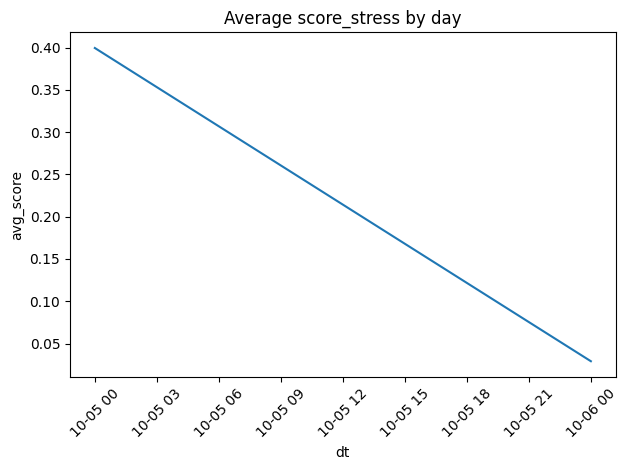

In [4]:
import matplotlib.pyplot as plt
pdf = daily.toPandas()
plt.figure()
plt.plot(pdf['dt'], pdf['avg_score'])
plt.title('Average score_stress by day')
plt.xlabel('dt')
plt.ylabel('avg_score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Top subreddits by average `score_stress` (choose a date)

In [5]:
from datetime import date
target_dt = None  # e.g., date(2025,10,1)
df = gold if target_dt is None else gold.where(F.col('dt') == F.lit(target_dt))
top_subs = (df.groupBy('subreddit')
    .agg(F.count('*').alias('n'), F.avg('score_stress').alias('avg_score'))
    .where(F.col('n') >= 5)
    .orderBy(F.desc('avg_score'))
)
top_subs.show(50, False)

+----------+---+--------------------+
|subreddit |n  |avg_score           |
+----------+---+--------------------+
|Stress    |10 |0.203823428764008   |
|depression|10 |0.039509462181013075|
+----------+---+--------------------+



### Plot: top 15 subreddits by average score

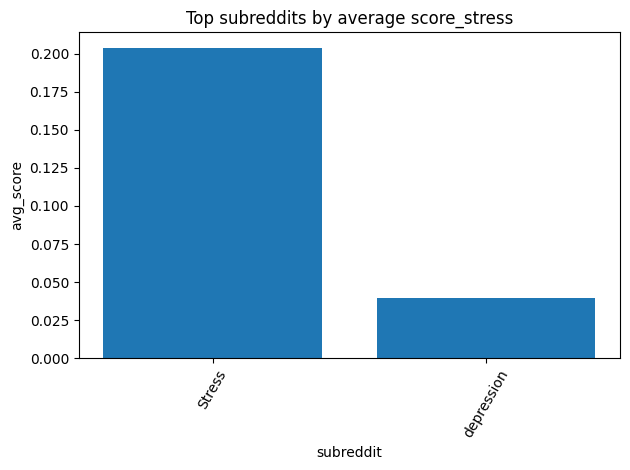

In [6]:
pdf2 = top_subs.limit(15).toPandas()
plt.figure()
plt.bar(pdf2['subreddit'], pdf2['avg_score'])
plt.title('Top subreddits by average score_stress')
plt.xlabel('subreddit')
plt.ylabel('avg_score')
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

## Time travel (optional)

In [7]:
from delta.tables import DeltaTable
dt = DeltaTable.forPath(spark, gold_path)
dt.history().show(20, truncate=False)
version = 0  # change as needed
prev = spark.read.format('delta').option('versionAsOf', version).load(gold_path)
prev.select('dt','post_id','score_stress').show(20, False)

+-------+-------------------+------+--------+---------+------------------------------------------+----+--------+---------+-----------+--------------+-------------+-------------------------------------------------------------+------------+-----------------------------------+
|version|timestamp          |userId|userName|operation|operationParameters                       |job |notebook|clusterId|readVersion|isolationLevel|isBlindAppend|operationMetrics                                             |userMetadata|engineInfo                         |
+-------+-------------------+------+--------+---------+------------------------------------------+----+--------+---------+-----------+--------------+-------------+-------------------------------------------------------------+------------+-----------------------------------+
|1      |2025-10-06 21:50:14|NULL  |NULL    |WRITE    |{mode -> Append, partitionBy -> ["dt"]}   |NULL|NULL    |NULL     |0          |Serializable  |true         |{numFiles ->